In [1]:
# import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# For MySQL connection
from sqlalchemy import create_engine

In [2]:
# Load dataset
df = pd.read_csv("Anesthesia_Dataset.csv")
df.head()

,PatientID,Age,Gender,BMI,SurgeryType,SurgeryDuration,AnesthesiaType,PreoperativeNotes,PostoperativeNotes,PainLevel,Complications,Outcome
0,1,33,M,32,Neurological,217 min,Local,"Hypertension, diabetes","Minimal pain, no complications",7,NaN,0
1,2,33,M,23,Cardiovascular,181 min,Local,"Stable, no allergies","Minimal pain, no complications",7,"Nausea, mild bleeding",1
2,3,58,F,24,Orthopedic,79 min,General,"Stable, no allergies","Minimal pain, no complications",3,"Nausea, mild bleeding",1
3,4,65,F,26,Orthopedic,210 min,Local,"Stable, no allergies","Pain, slow recovery",7,Delayed recovery,1
4,5,65,M,28,Neurological,221 min,General,"Stable, no allergies","Pain, slow recovery",5,Respiratory distress,0


# EXPLORATORY DATA ANALYSIS (EDA)

In [4]:
# Basic data understanding
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   PatientID           300 non-null    int64 
 1   Age                 300 non-null    int64 
 2   Gender              300 non-null    object
 3   BMI                 300 non-null    int64 
 4   SurgeryType         300 non-null    object
 5   SurgeryDuration     300 non-null    object
 6   AnesthesiaType      300 non-null    object
 7   PreoperativeNotes   300 non-null    object
 8   PostoperativeNotes  300 non-null    object
 9   PainLevel           300 non-null    int64 
 10  Complications       227 non-null    object
 11  Outcome             300 non-null    int64 
dtypes: int64(5), object(7)
memory usage: 28.3+ KB


PatientID              0
Age                    0
Gender                 0
BMI                    0
SurgeryType            0
SurgeryDuration        0
AnesthesiaType         0
PreoperativeNotes      0
PostoperativeNotes     0
PainLevel              0
Complications         73
Outcome                0
dtype: int64

In [7]:
# Data cleaning
# Clean column names (minimal & safe)
df.columns = df.columns.str.strip().str.lower()

print("Columns:", df.columns)

Columns: Index(['patientid', 'age', 'gender', 'bmi', 'surgerytype', 'surgeryduration',
       'anesthesiatype', 'preoperativenotes', 'postoperativenotes',
       'painlevel', 'complications', 'outcome'],
      dtype='object')


In [8]:
# Replacing null with "No Complications"
df['complications'] = df['complications'].fillna("No Complication")

In [9]:
df['complications'].value_counts()

complications
Respiratory distress     83
Nausea, mild bleeding    80
No Complication          73
Delayed recovery         64
Name: count, dtype: int64

In [13]:
# Understand distribution of individual features
df['age'].describe()
df['bmi'].describe()
df['painlevel'].describe()

count    300.000000
mean       4.496667
std        1.646925
min        2.000000
25%        3.000000
50%        4.000000
75%        6.000000
max        7.000000
Name: painlevel, dtype: float64

In [14]:
# For categorical
df['gender'].value_counts()
df['complications'].value_counts()
df['outcome'].value_counts()

outcome
0    150
1    150
Name: count, dtype: int64

# Data Visualization 

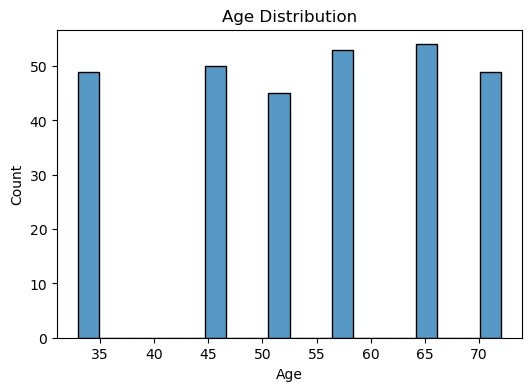

In [15]:
# Age Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['age'], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

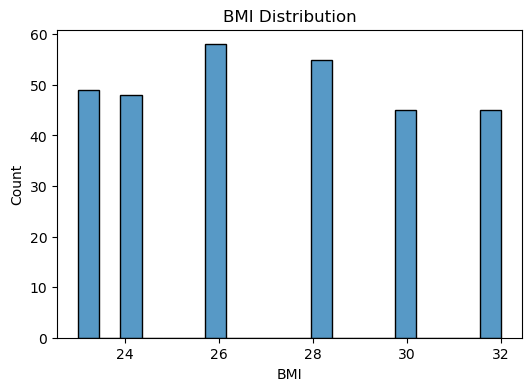

In [16]:
# BMI Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['bmi'], bins=20)
plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Count")
plt.show()

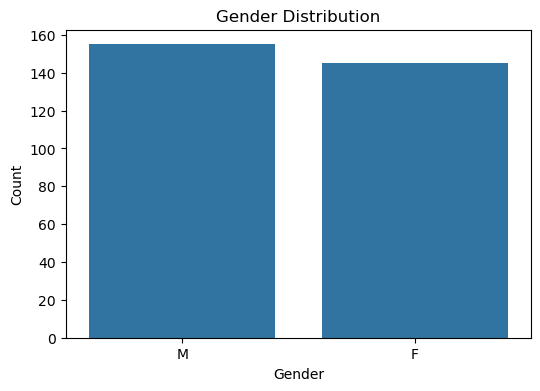

In [17]:
# Gender Count
plt.figure(figsize=(6,4))
sns.countplot(x='gender', data=df)
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

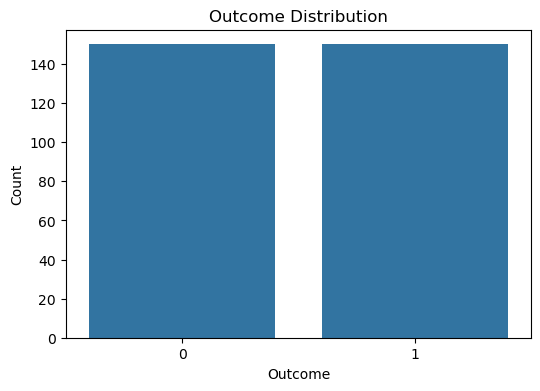

In [18]:
# Outcome Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='outcome', data=df)
plt.title("Outcome Distribution")
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.show()

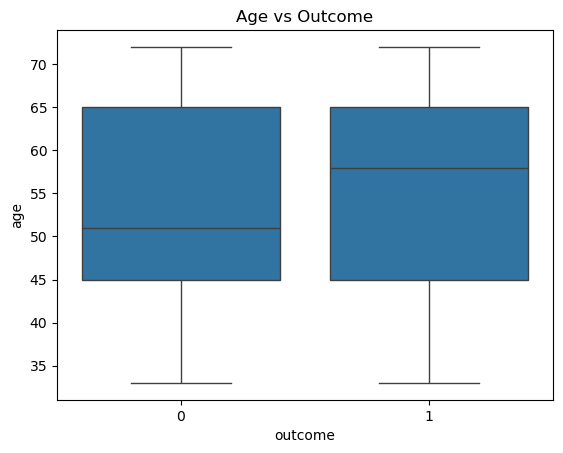

In [21]:
# Age VS Outcome
sns.boxplot(x='outcome', y='age', data=df)
plt.title("Age vs Outcome")
plt.show()

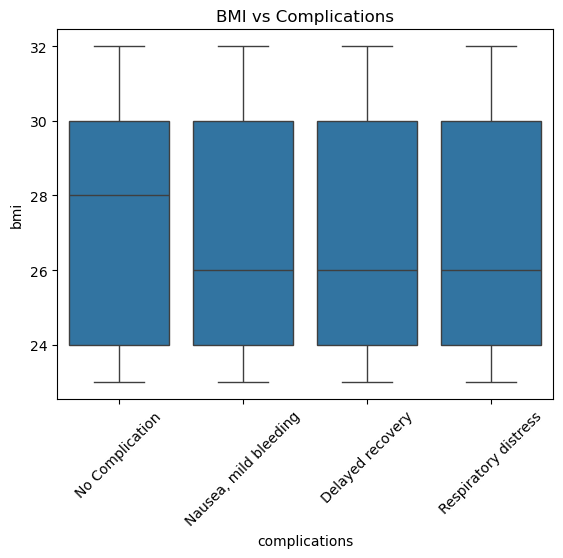

In [22]:
# BMI vs Complications
sns.boxplot(x='complications', y='bmi', data=df)
plt.title("BMI vs Complications")
plt.xticks(rotation=45)
plt.show()

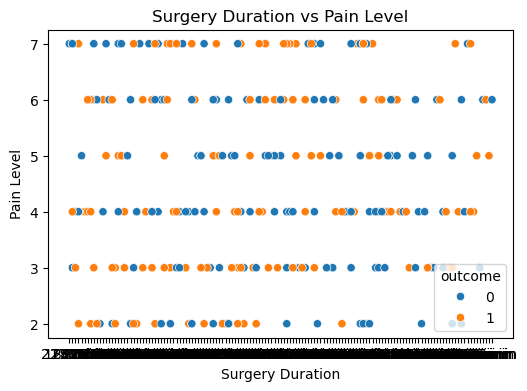

In [26]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='surgeryduration', y='painlevel', hue='outcome', data=df)

plt.title("Surgery Duration vs Pain Level")
plt.xlabel("Surgery Duration")
plt.ylabel("Pain Level")

plt.show()

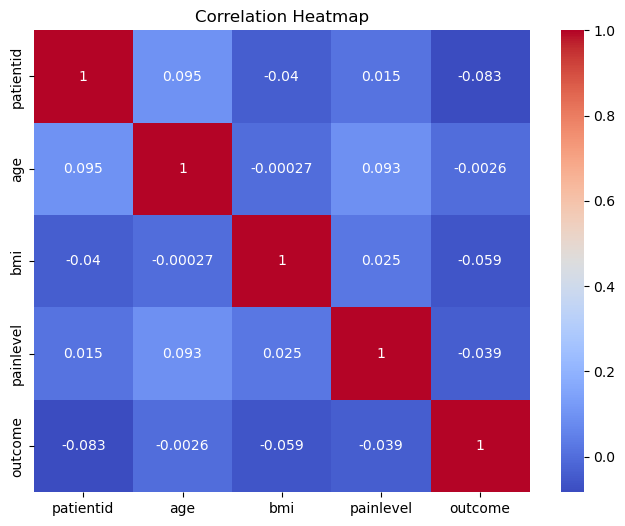

In [20]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()